In [27]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:

import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym

import dsrl.infos as dsrl_infos
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from dsrl_model.utils.models import ExpCostModel

In [29]:
def load_cost_model(obs_dim, act_dim, hidden_size, path, device):
    cost_model = ExpCostModel(
        obs_dim=obs_dim + act_dim, hidden_sizes=[hidden_size, hidden_size]
    ).to(device)
    cost_model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    cost_model.eval()
    return cost_model

In [30]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [104]:
def get_post_processed_dataset(env, data):
    density = 1.0
    cbins, rbins = 10, 50
    max_npb, min_npb = 30, 2
    
    inpaint_ranges = ((0.0, 1.0, 0.0, 0.5),)
    
    data = env.pre_process_data(
        data_dict=data,
        inpaint_ranges=inpaint_ranges,
        density=density,
        cbins=cbins,
        rbins=rbins,
        max_npb=max_npb,
        min_npb=min_npb,
    )
    return data


def get_dataset(env, task):
    data = env.get_dataset()
    data = get_post_processed_dataset(env, data)
    return data

In [105]:
def get_cost_info_data(data, cost_model, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    reward_trajs, true_cost_trajs, pred_cost_trajs = [], [], []
    rewards, costs = data["rewards"], data["costs"]
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)    
    pred_costs = cost_model(
        torch.cat([observations, actions], dim=1), use_sigmoid=True
    ).detach().squeeze().cpu().numpy()
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        reward_trajs.append(np.sum(rewards[start:end]))
        true_cost_trajs.append(np.sum(costs[start:end]))
        pred_cost_trajs.append(np.sum(pred_costs[start:end]))
    return np.array(reward_trajs), np.array(true_cost_trajs), np.array(pred_cost_trajs)

In [106]:
def traj_binning(traj_cost, bin_size=25):
    min_cost, max_cost = traj_cost.min(), traj_cost.max()
    c = min_cost
    bins = []
    while c < max_cost:
        bins.append([])
        c = min(bin_size + c, max_cost)
    
    for idx, cost in enumerate(traj_cost):
        i = min(int(cost // bin_size), len(bins)-1)    
        bins[i].append(idx)
    
    return bins

In [107]:
def light_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]  # convert named color to hex
    except KeyError:
        c = color  # if it's not a named color, it might already be hex or RGB

    rgb = mcolors.to_rgb(c)  # convert to RGB format
    light_color = [(1 - amount) * channel + amount for channel in rgb]  # blend with white
    return light_color


def plot_pred_cost_trajectories(pred_traj_cost, bins):
    fig, ax = plt.subplots(figsize=(6, 4))
    # color = "red"
    for i, bin in enumerate(bins):
        costs = pred_traj_cost[bin]
        # amount = (0.9 - 0.9/len(bins) * i)
        ax.plot(costs, [i]*len(bin), "o")

In [125]:
# task = "OfflineHopperVelocityGymnasium-v1"
task = "OfflinePointCircle2Gymnasium-v0"
device = torch.device("cpu")
cost_model_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safepcl/{task}/torch_save/cost_model_model_0.pt"

Loading dataset from /home/returaj/.dsrl/datasets/SafetyPointCircle2Gymnasium-v0-300-895.hdf5


load datafile: 100%|██████████| 7/7 [00:00<00:00,  9.76it/s]


rmax = 54.02184295654297, rmin = 20.478347778320312
cmax = 299.0, cmin = 0.0
before filter: traj num = 895, transitions num = 447500
after filter: traj num = 895


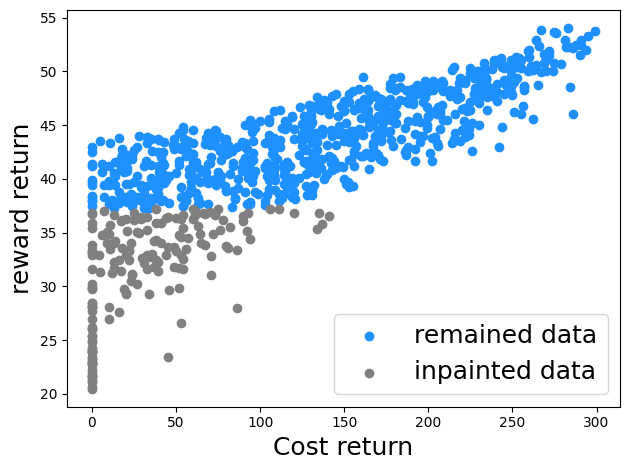

In [126]:
env, obs_dim, act_dim = get_env(task)
data = get_dataset(env, task)

In [ ]:
cost_model = load_cost_model(obs_dim, act_dim, 256, cost_model_path, device)

In [111]:
traj_reward, true_traj_cost, pred_traj_cost = get_cost_info_data(data, cost_model, norm=True)
cost_bins = traj_binning(true_traj_cost)

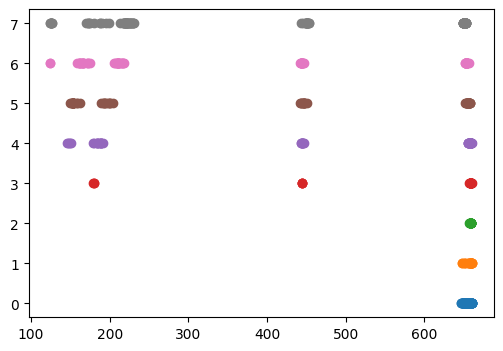

In [112]:
plot_pred_cost_trajectories(pred_traj_cost, cost_bins)